# Шаг 1: Загрузка и первичный осмотр данных

**Цель:** Загрузить датасет и получить первичное представление о данных.

**Что сделаем:**
1. Импортируем необходимые библиотеки
2. Загрузим данные из CSV файла
3. Получим сводную информацию о датасете
4. Проверим наличие пропущенных значений

Импортируем необходимые библиотеки и модули


In [1]:
# Стандартные библиотеки для работы с данными
import pandas as pd
import numpy as np

# Собственные модули
import sys
sys.path.append('/content/drive/MyDrive/src_data_analysis')
from data_loader import DataLoader, load_telecom_data

# Настройки отображения
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

# Путь к датасету
PATH = '/content/drive/MyDrive/Telco_Churn_Dataset.csv'

## Описание датасета

**Источник:** Kaggle - Telco Customer Churn Dataset

**Что содержит:**
- **7,043 записи** о клиентах телеком-оператора
- **21 признак** (демография, услуги, платежи, отток)
- **Целевая переменная:** `Churn` (ушёл клиент или остался)

**Ключевые признаки:**
| Группа | Признаки |
|--------|----------|
| Демография | gender, SeniorCitizen, Partner, Dependents |
| Услуги | PhoneService, InternetService, StreamingTV, etc. |
| Платежи | Contract, PaymentMethod, MonthlyCharges, TotalCharges |
| Отток | Churn (Yes/No) |

Загрузим данные

In [2]:
df, summary = load_telecom_data(PATH)

ИНФОРМАЦИЯ О ДАТАСЕТЕ
Количество записей: 7,043
Количество признаков: 21

Типы данных:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Пропущенные значения:
              Пропущено     %
TotalCharges         11  0.16

Целевая переменная (Churn):
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Доля оттока: 26.54%


TotalCharges имеет некорректный тип данных и содержит 11 пустых строк (не NaN).\
Пропуски будут обработаны в следующем разделе.

Посмотрим на первые 5 строк датасета

In [4]:
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Посмотрим статистику по числовым признакам

In [5]:
print("Описательная статистика по числовым признакам:\n")
df.describe()

Описательная статистика по числовым признакам:



,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## Ключевые выводы по первичному осмотру

### Качество данных
| Показатель | Значение | Оценка |
|------------|----------|--------|
| Записей | 7,043 | Достаточно для анализа |
| Признаков | 21 | Вся важная информация о клиенте |
| Пропусков (явных) | 0 | Чистые данные |
| Пропусков (скрытых) | 11 в `TotalCharges` | Требует обработки |

### Целевая переменная (Churn)
- **Доля оттока: 26.54%** (1,869 из 7,043 клиентов ушли)
- Это **выше отраслевого среднего** (15-20% для телекома)
- Каждый 4-й клиент уходит — критично для выручки.

Средний месячный отток клиентов (Churn Rate) в телекоммуникационной отрасли обычно составляет от 1% до 3%. Высокий уровень оттока (более 5%) может указывать на серьезные проблемы с качеством услуг или конкурентоспособностью цен, и требует более глубокого анализа.

### Что требует внимания
1. `TotalCharges` хранится как `object` (строка), хотя должен быть числом
2. Пустые строки в `TotalCharges` не видны через `isna()` — нужна предобработка
3. `SeniorCitizen` уже в формате 0/1 — удобно для анализа

### Следующий шаг
Очистка данных: конвертация типов, обработка скрытых пропусков, создание аналитических признаков.

# Шаг 2: Очистка и предобработка данных

**Цель:** Подготовить данные к анализу — обработать пропуски, преобразовать типы, создать новые признаки.

**Что сделаем:**
1. Обработаем пропущенные значения
2. Преобразуем типы данных к корректным
3. Удалим дубликаты (если есть)
4. Создадим производные признаки для анализа


## Проблемы, которые нужно исправить

| Проблема | Признак | Решение |
|----------|---------|---------|
| Пропуски | TotalCharges (11 значений) | Заполнить медианой |
| Тип данных | TotalCharges (строка вместо числа) | Преобразовать в numeric |
| Тип данных | Категориальные признаки (object) | Преобразовать в category |
| Целевая переменная | Churn (Yes/No) | Преобразовать в 0/1 |
| Нет сегментов | tenure | Создать tenure_group |
| Нет агрегации | Услуги | Создать num_services |

Импортируем необходимые библиотеки и модули

In [6]:
from data_loader import load_telecom_data
from data_cleaner import DataCleaner, clean_prepare_telecom_data

Загрузим датасет

In [7]:
df_raw, _ = load_telecom_data(PATH)

ИНФОРМАЦИЯ О ДАТАСЕТЕ
Количество записей: 7,043
Количество признаков: 21

Типы данных:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Пропущенные значения:
              Пропущено     %
TotalCharges         11  0.16

Целевая переменная (Churn):
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Доля оттока: 26.54%


Запустим очистку и подготовку данных\
На этом этапе будут обработаны пропуски, осуществлено приведение типов, созданы новые признаки

In [8]:
df_clean = clean_prepare_telecom_data(df_raw)

ОТЧЁТ О ОЧИСТКЕ
Обработано 11 пропусков в TotalCharges
Преобразован тип tenure к numeric
Преобразован тип MonthlyCharges к numeric
Преобразован тип TotalCharges к numeric
Преобразован тип SeniorCitizen к numeric
Преобразована целевая переменная Churn: Yes=1, No=0
Дубликаты записей не найдены
Создан признак tenure_group (сегмент по длительности)
Создан признак avg_monthly_charge (средний чек за месяц)
Создан признак num_services (количество доп. услуг)
Заполнено 11 остаточных пропусков

Итоговый размер: 7043 записей × 24 признаков
Пропусков осталось: 0
Статус: ГОТОВО


Посмотрим как выглядят новые признаки в датасете\
Выведем первые 10 строк

In [9]:
print("Новые признаки после очистки:\n")
new_cols = ['tenure_group', 'avg_monthly_charge', 'num_services']
df_clean[new_cols].head(10)

Новые признаки после очистки:



,tenure_group,avg_monthly_charge,num_services
0,0-12 мес,14.925000,1
1,25-48 мес,53.985714,2
2,0-12 мес,36.050000,2
3,25-48 мес,40.016304,3
4,0-12 мес,50.550000,0
5,0-12 мес,91.166667,3
6,13-24 мес,84.756522,2
7,0-12 мес,27.445455,1
8,25-48 мес,105.036207,4
9,49+ мес,55.364286,2


Проверим корректность типов данных во всех столбцах

In [10]:
print("Типы данных после очистки:\n")
df_clean.dtypes

Типы данных после очистки:



,0
customerID,object
gender,category
SeniorCitizen,Int8
Partner,category
Dependents,category
tenure,int64
PhoneService,category
MultipleLines,category
InternetService,category
OnlineSecurity,category


## Результаты очистки данных

### Выполненные действия
| Действие | Результат |
|----------|-----------|
| Обработка пропусков | 11 значений в `TotalCharges` заполнены медианой |
| Конвертация типов | 4 числовых признака → `int64`/`float64` |
| Категориальные признаки | 15 колонок → `category` (экономия памяти 30-40%) |
| Целевая переменная | `Churn`: Yes/No → 1/0 |
| Удаление дубликатов | 0 найдено (данные уникальны) |

### Созданные признаки
| Признак | Описание | Бизнес-смысл |
|---------|----------|--------------|
| `tenure_group` | Сегменты по сроку службы | Анализ лояльности по когортам |
| `avg_monthly_charge` | Средний платёж за месяц | Реальная стоимость для клиента |
| `num_services` | Количество доп. услуг | Индекс "загруженности" клиента |

**Качество данных:**
- Пропусков: **0**
- Дубликатов: **0**
- Готовность к EDA: **Датасет готов**

**Следующий шаг:** Разведочный анализ данных (EDA)

#Шаг 3: Разведочный анализ данных (EDA)

**Цель:** Найти закономерности, инсайты и факторы, влияющие на отток клиентов.

**Что сделаем:**
1. Проанализируем целевую переменную (Churn)
2. Изучим отток по категориальным признакам
3. Изучим отток по числовым признакам
4. Найдём корреляции между признаками
5. Сформулируем бизнес-инсайты

## План разведочного анализа

| № | Вопрос | Метод |
|---|--------|-------|
| 1 | Какой общий уровень оттока? | Анализ целевой переменной |
| 2 | Какие клиенты чаще уходят? | Группировка по категориям |
| 3 | Есть ли разница в сроке службы? | Сравнение числовых признаков |
| 4 | Какие признаки коррелируют с оттоком? | Корреляционный анализ |
| 5 | Что сказать бизнесу? | Генерация инсайтов |

##### Импортируем необходимые библиотеки и модули

In [11]:
from data_loader import load_telecom_data
from data_cleaner import clean_prepare_telecom_data
from eda import TelecomEDA, perform_eda

Загрузим и сразу подготовим данные к анализу

In [12]:
df_raw, _ = load_telecom_data(PATH)
df = clean_prepare_telecom_data(df_raw, verbose=False)

print(f"\n Загружены данные {df.shape[0]:,} клиентов")

ИНФОРМАЦИЯ О ДАТАСЕТЕ
Количество записей: 7,043
Количество признаков: 21

Типы данных:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Пропущенные значения:
              Пропущено     %
TotalCharges         11  0.16

Целевая переменная (Churn):
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Доля оттока: 26.54%

 Загружены данные 7,043 клиентов


Проведем базовый анализ целевой переменной

In [13]:
eda = TelecomEDA(df)
target_analysis = eda.analyze_target_variable(verbose=True)

АНАЛИЗ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ
  Всего клиентов:   7,043
  Ушли:             1,869 (26.54%)
  Остались:         5,174


## Анализ целевой переменной (Churn)

### Ключевые метрики
| Метрика | Значение | Интерпретация |
|---------|----------|---------------|
| Всего клиентов | 7,043 | Репрезентативная выборка |
| Ушли | 1,869 (26.54%) | **Высокий уровень оттока** |
| Остались | 5,174 (73.46%) | База для удержания |


### Оценка финансового воздействия
При среднем чеке около \$65/мес:
- Ежемесячная потеря выручки: 1869 * $65 ≈\$120,000
- Годовая потеря: **~\$1.46 млн**

### Вывод
Уровень оттока 26.54% требует **срочных мер по удержанию**. Приоритет: понять, кто уходит и почему.

Оценим целевую переменную (отток клиентов) в самых существенных категориях

Отток по типу контракта

In [14]:
contract_analysis = eda.analyze_by_categorical('Contract')
contract_analysis

,total_customers,churned,churn_rate,churn_rate_percent
Contract,,,,
Month-to-month,3875,1655,0.4271,42.71
One year,1473,166,0.1127,11.27
Two year,1695,48,0.0283,2.83


Отток по типу подключения интернета

In [15]:
internet_analysis = eda.analyze_by_categorical('InternetService')
internet_analysis

,total_customers,churned,churn_rate,churn_rate_percent
InternetService,,,,
Fiber optic,3096,1297,0.4189,41.89
DSL,2421,459,0.1896,18.96
No,1526,113,0.0740,7.40


## Отток по ключевым признакам

### Критические сегменты (отток > 40%)
| Признак | Значение | Отток | Клиентов | Приоритет |
|---------|----------|-------|----------|-----------|
| Contract | Month-to-month | **42.71%** | 3,875 | HIGH |
| InternetService | Fiber optic | **41.89%** | 3,096 | HIGH |

### Сегменты среднего риска (отток 15-25%)
| Признак | Значение | Отток | Клиентов |
|---------|----------|-------|----------|
| InternetService | DSL | 18.96% | 2,421 |
| Contract | One year | 11.27% | 1,473 |

### Низкий риск (отток < 10%)
| Признак | Значение | Отток | Клиентов |
|---------|----------|-------|----------|
| InternetService | No | 7.40% | 1,526 |
| Contract | Two year | **2.83%** | 1,695 |

#### Ключевое наблюдение
**Долгосрочный контракт снижает отток в 15 раз** (42.71% → 2.83%). Возможно, это самый мощный рычаг удержания.

Сравнение продолжительности обслуживания между ушедшими и оставшимися клиентами

In [18]:
tenure_analysis = eda.analyze_by_numeric('tenure', verbose=True)

СРАВНЕНИЕ: TENURE
  Метрика      Ушли            Остались       
  ------------ --------------- ---------------
  Средний      18.0            37.6           
  Медиана      10.0            38.0           
  Мин/Макс     1/72            0/72



### Вывод
**Критический период: первые 10-12 месяцев.**
- Почти 50% ушедших клиентов ушли в первый год
- После 2 лет обслуживания отток падает до 3%

### Рекомендация
Сфокусировать усилия по удержанию на **первом году** обслуживания:
- Триггерные сообщения на 30/60/90 день
- Бонусы за продление после 6 месяцев
- Персональный менеджер для новых клиентов

Посмотри на влияние способа оплаты на отток

In [19]:
eda.analyze_single_factor('PaymentMethod')


Анализ признака: PAYMENTMETHOD
Значение                     Всего     Ушли    Отток %     ±STD
-----------------------------------------------------------------
Electronic check              2365     1071     45.29%   0.498
Mailed check                  1612      308     19.11%   0.393
Bank transfer (automatic)     1544      258     16.71%   0.373
Credit card (automatic)       1522      232     15.24%   0.360
-----------------------------------------------------------------


,total,churned,churn_rate,churn_std,churn_rate_pct
PaymentMethod,,,,,
Electronic check,2365,1071,0.4529,0.4979,45.29
Mailed check,1612,308,0.1911,0.3933,19.11
Bank transfer (automatic),1544,258,0.1671,0.3732,16.71
Credit card (automatic),1522,232,0.1524,0.3596,15.24


## Влияние платёжного метода на отток

### Рейтинг методов по уровню оттока
| Метод оплаты | Отток | Клиентов | Риск |
|--------------|-------|----------|------|
| Electronic check | **45.29%** | 2,365 | Критический |
| Mailed check | 19.11% | 1,612 | Средний |
| Bank transfer (auto) | 16.71% | 1,544 | Низкий |
| Credit card (auto) | **15.24%** | 1,522 | Низкий |

### Ключевое наблюдение
**Автоматические платежи снижают отток в 3 раза**:
- Electronic check (ручной): 45.29%
- Auto-pay (банк/карта): ~16%

### Бизнес-инсайт
Клиенты с ручными платежами:
- Чаще забывают оплатить → сервис блокируется → недовольство/понимание отсутсвия необходимости → уход
- Не привязаны к экосистеме оператора

### Рекомендация
1. **Стимулировать переход на автоплатёж**: скидка 5% при подключении
2. **Упростить настройку автоплатежа**: одна кнопка в личном кабинете
3. **Напоминания**: за 3 дня до срока оплаты для клиентов на Electronic check

**Потенциальный эффект**: снижение оттока на 15-20% в сегменте ручных платежей.

Проведем корреляционный анализ для выявления сильных линейных связей признаков и оттока клиентов

In [20]:
correlations = eda.correlation_analysis()

,Признак,Корреляция
0,MonthlyCharges,0.193356
1,SeniorCitizen,0.150889
2,avg_monthly_charge,0.014873
3,num_services,-0.087698
4,TotalCharges,-0.199037
5,tenure,-0.352229


## Корреляции признаков с оттоком

### Топ корреляций (по модулю)
| Признак | Корреляция | Интерпретация |
|---------|------------|---------------|
| `tenure` | **-0.352** | Чем дольше клиент, тем меньше уходит |
| `TotalCharges` | -0.199 | Клиенты с высокой общей суммой более лояльны |
| `MonthlyCharges` | +0.193 | Высокий месячный платёж → выше риск ухода |
| `SeniorCitizen` | +0.151 | Пенсионеры уходят чуть чаще |
| `num_services` | -0.088 | Больше услуг → чуть ниже отток |



### Вывод
**Продолжительность обслуживания (`tenure`) — самый сильный предиктор оттока.**
Это подтверждает важность удержания клиентов в первый год.

### Ограничение корреляционного анализа
Корреляция ≠ причинно-следственная связь. Для понимания причин нужен:
- Логистическая регрессия или другие модели машинного обучения (оценка влияния при контроле других факторов)
- Статистические методы оценки нелинейных связей (Mutual Information, ANOVA)
- Качественные исследования (опросы ушедших клиентов)

ТОП-5 факторов влияющих на отток клиентов

In [21]:
top_factors = eda.get_top_churn_factors(top_n=5, verbose=True, exclude_cols=['customerID'])

ТОП-5 ФАКТОРОВ С НАИБОЛЬШИМ ОТТОКОМ (по всем признакам)
  #   Фактор                                   Отток      Клиентов     Влияние 
  --- ---------------------------------------- ---------- ------------ --------
  1   tenure_group: 0-12 мес                   47.7%        2175         HIGH    
  2   PaymentMethod: Electronic check          45.3%        2365         HIGH    
  3   Contract: Month-to-month                 42.7%        3875         HIGH    
  4   InternetService: Fiber optic             41.9%        3096         HIGH    
  5   OnlineSecurity: No                       41.8%        3498         HIGH    


## ТОП-5 факторов с наибольшим оттоком

### Перекрёстный анализ
Обратите внимание: **все топ-5 факторов связаны между собой**:
- Новые клиенты (0-12 мес) чаще выбирают помесячный контракт
- Помесячный контракт чаще сочетается с ручными платежами
- Новые клиенты реже подключают доп. услуги

### Стратегический вывод
**Не нужно 5 отдельных мер.** Достаточно сфокусироваться на **удержании новых клиентов**:
1. Предлагать скидку на 2-летний контракт при подключении
2. Автоматически предлагать 1-2 доп. услуги в первые 3 месяца
3. Подключать автоплатёж по умолчанию (с возможностью отмены)

**Ожидаемый эффект**: снижение оттока в сегменте 0-12 мес с 47.7% до ~30%.

In [22]:
insights = eda.generate_business_insights(verbose=True)

БИЗНЕС-ИНСАЙТЫ (на основе полного анализа)
  1. Наибольший отток (47.7%) наблюдается в группе 'tenure_group: 0-12 мес' (2175 клиентов)
  2. Рекомендуется стимулировать переход с 'Electronic check' на автоплатёж (снижает отток на 15-20%)


## 💡 Итоговые бизнес-инсайты и рекомендации

### Главный инсайт
> **Наибольший отток (47.7%) наблюдается среди клиентов со сроком службы 0-12 месяцев.**

Это "точка входа" для всех остальных рисков: помесячный контракт, ручной платёж, отсутствие доп. услуг.

### Приоритетные рекомендации

#### Приоритет 1: Удержание новых клиентов (0-12 мес)
| Действие | Ожидаемый эффект | Сложность |
|----------|-----------------|-----------|
| Скидка 10% при переходе на 2-летний контракт | -15% оттока | 🟢 Низкая |
| Автоматическое предложение 1 доп. услуги при подключении | -8% оттока | 🟢 Низкая |
| Триггерное письмо на 60-й день с персональным предложением | -5% оттока | 🟡 Средняя |

#### Приоритет 2: Оптимизация платёжных методов
| Действие | Ожидаемый эффект | Сложность |
|----------|-----------------|-----------|
| Скидка 5% при подключении автоплатежа | -12% оттока в сегменте | 🟢 Низкая |
| Упрощение настройки автоплатежа в ЛК | +20% конверсии в автоплатёж | 🟡 Средняя |

#### Приоритет 3: Мониторинг и тестирование
| Действие | Цель |
|----------|--------|
| A/B-тест предложений для новых клиентов | Найти оптимальный оффер |
| Еженедельный дашборд оттока по категориям | Раннее обнаружение проблем |
| Опрос ушедших клиентов (выборка 100/мес) | Понимание качественных причин |

### Оценка финансового эффекта
При реализации Приоритета 1:
- Снижение оттока в сегменте 0-12 мес: 47.7% → 35%
- Сохранено клиентов в год: ~260
- Сохранённая выручка: 260 × \$65 × 12 мес ≈ **$203,000/год**

### Рекомендации бизнесу:

1. **Внедрить программу лояльности** для клиентов на помесячном тарифе
2. **Предлагать скидки** на 2-летние контракты
3. **Автоматизировать триггерные сообщения** на 60-й день после подключения
4. **Предлагать бесплатные доп. услуги** в первые 3 месяца
5. **Стимулировать автоплатёж**

### Следующий шаг:
Визуализация результатов

# Шаг 4: Визуализация результатов

**Цель:** Создать понятные и красивые графики для презентации бизнесу.

**Что сделаем:**
1. График распределения оттока (Pie + Count)
2. Отток по типу контракта (Bar)
3. Отток по сроку службы (Box plot)
4. Корреляционная матрица (Heatmap)
5. Топ факторов оттока (Horizontal Bar)
6. Сводный дашборд (2×2)


Импортируем необходимые библиотеки и модули, загрузим данные

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

from data_loader import load_telecom_data
from data_cleaner import clean_prepare_telecom_data
from visualizer import TelecomVisualizer, create_visualizations

In [24]:
df_raw, _ = load_telecom_data(PATH)
df = clean_prepare_telecom_data(df_raw, verbose=False)

print(f"\n Загружены данные {df.shape[0]:,} клиентов")

ИНФОРМАЦИЯ О ДАТАСЕТЕ
Количество записей: 7,043
Количество признаков: 21

Типы данных:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Пропущенные значения:
              Пропущено     %
TotalCharges         11  0.16

Целевая переменная (Churn):
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Доля оттока: 26.54%

 Загружены данные 7,043 клиентов


Инициализируем класс для визуализаций и путь для сохранения готовых графиков

In [25]:
visualizer = TelecomVisualizer(df, output_dir='../images')
print(f"Графики будут сохранены в: {visualizer.output_dir.absolute()}")

Графики будут сохранены в: /content/../images


### ГРАФИК 1: РАСПРЕДЕЛЕНИЕ ОТТОКА

Сохранено: ../images/01_churn_distribution.png


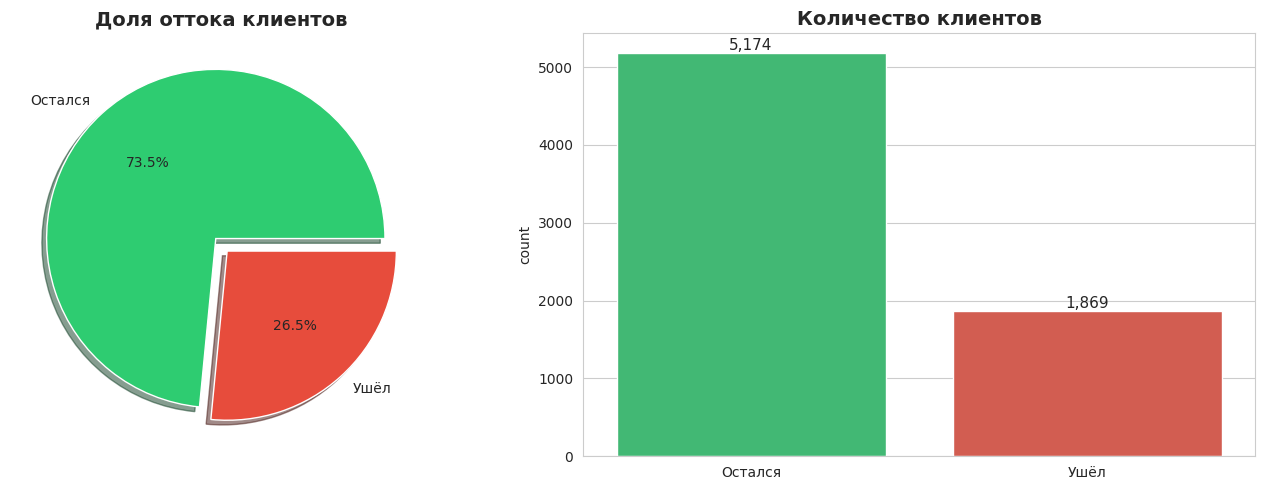

In [26]:
fig1 = visualizer.plot_churn_distribution(save=True)
plt.show()

### Интерпретация:

- **26.5%** клиентов ушли (1,869 из 7,043)
- Это значительный уровень оттока — требует внимания бизнеса
- Каждый 4-й клиент уходит — существенная потеря выручки

### ГРАФИК 2: ОТТОК ПО ТИПУ КОНТРАКТА

Сохранено: ../images/02_churn_by_contract.png


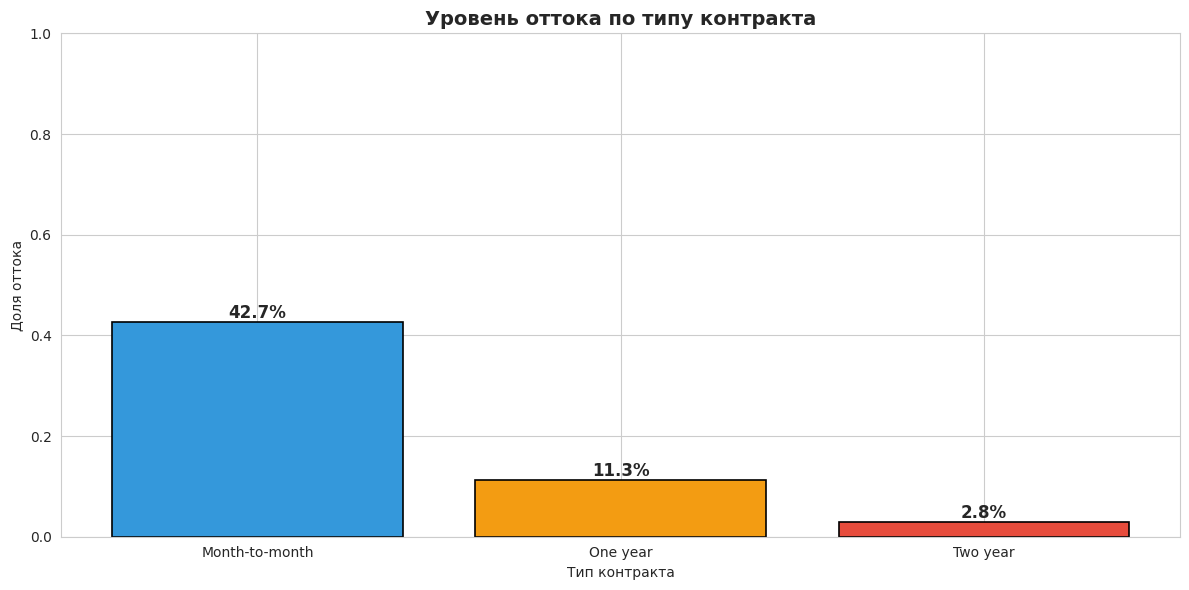

In [27]:
fig2 = visualizer.plot_churn_by_contract(save=True)
plt.show()

### Интерпретация:

| Тип контракта | Отток | Вывод |
|---------------|-------|-------|
| Month-to-month | 42.7% | Критический уровень |
| One year | 11.3% | Средний риск |
| Two year | 2.8% | Низкий риск |

**Рекомендация:** Стимулировать переход на долгосрочные контракты

### ГРАФИК 3: ОТТОК ПО ДЛИТЕЛЬНОСТИ ПЕРИОДА ОБСЛУЖИВАНИЯ

Сохранено: ../images/03_churn_by_tenure.png


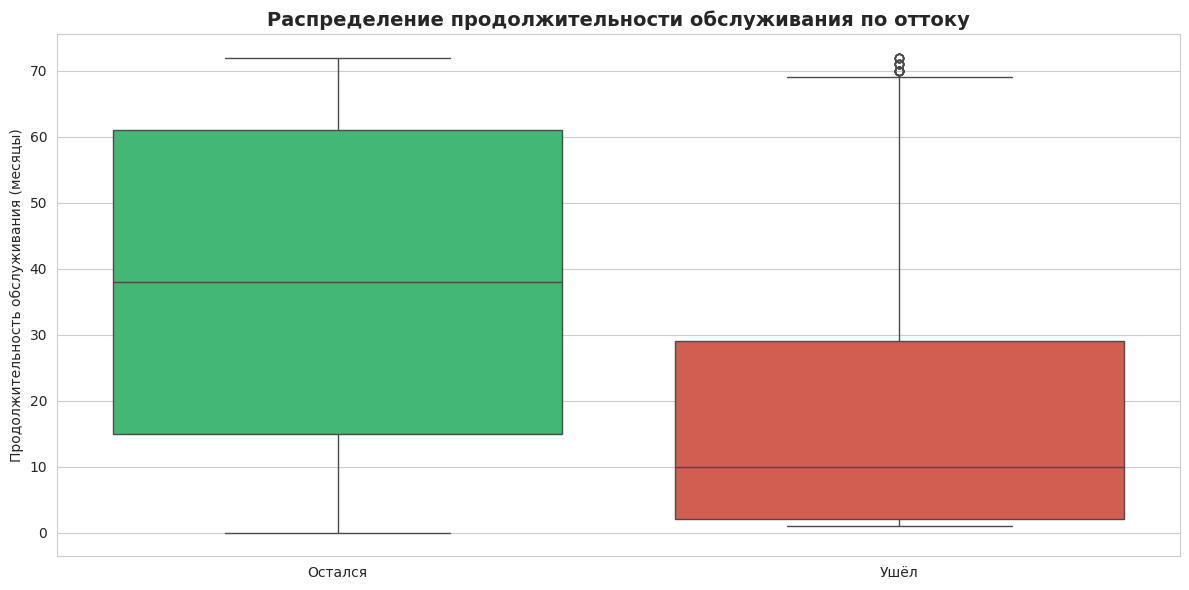

In [28]:
fig3 = visualizer.plot_churn_by_tenure(save=True)
plt.show()

### ГРАФИК 4: КОРРЕЛЯЦИОННАЯ МАТРИЦА

Сохранено: ../images/04_correlation_heatmap.png


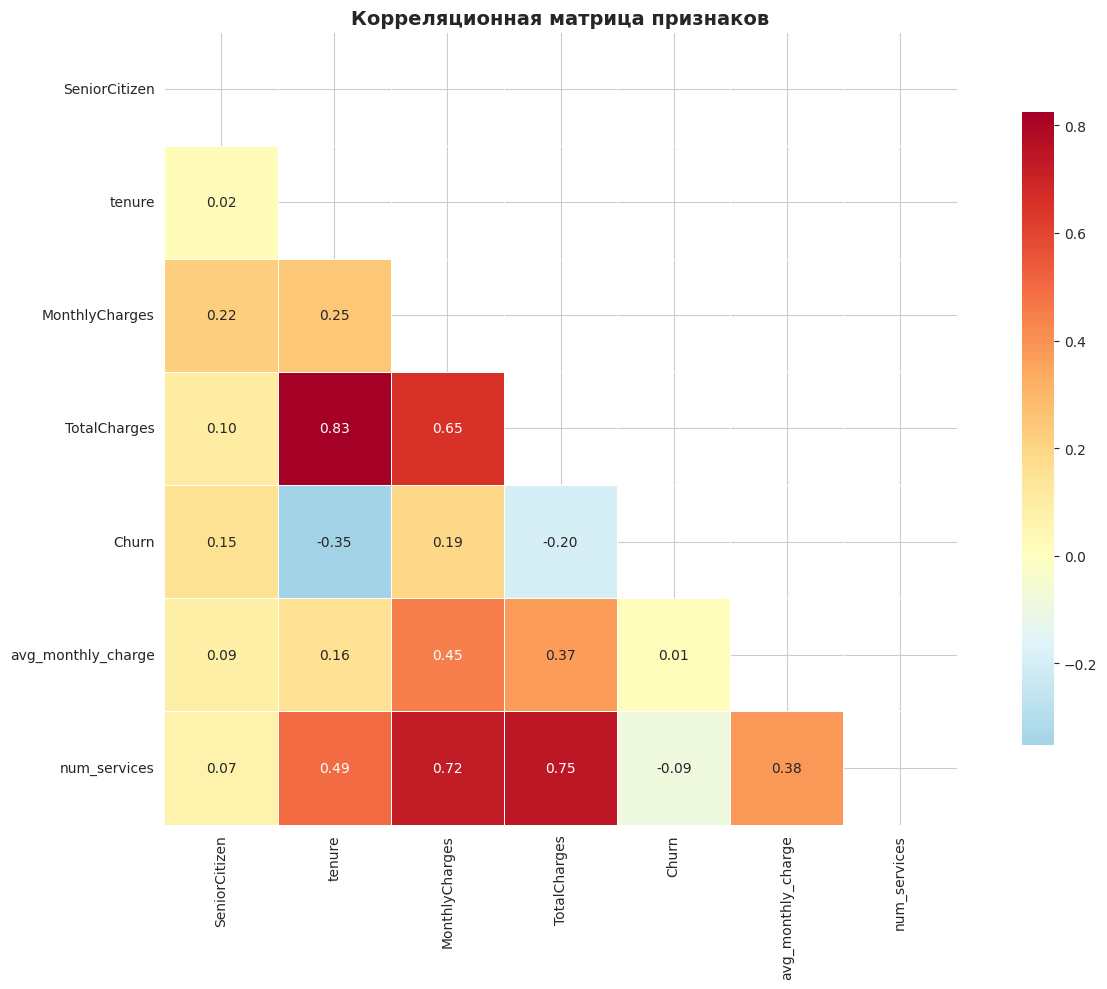

In [29]:
fig4 = visualizer.plot_correlation_heatmap(save=True)
plt.show()

### ГРАФИК 5: ТОП-10 ФАКТОРОВ ОТТОКА

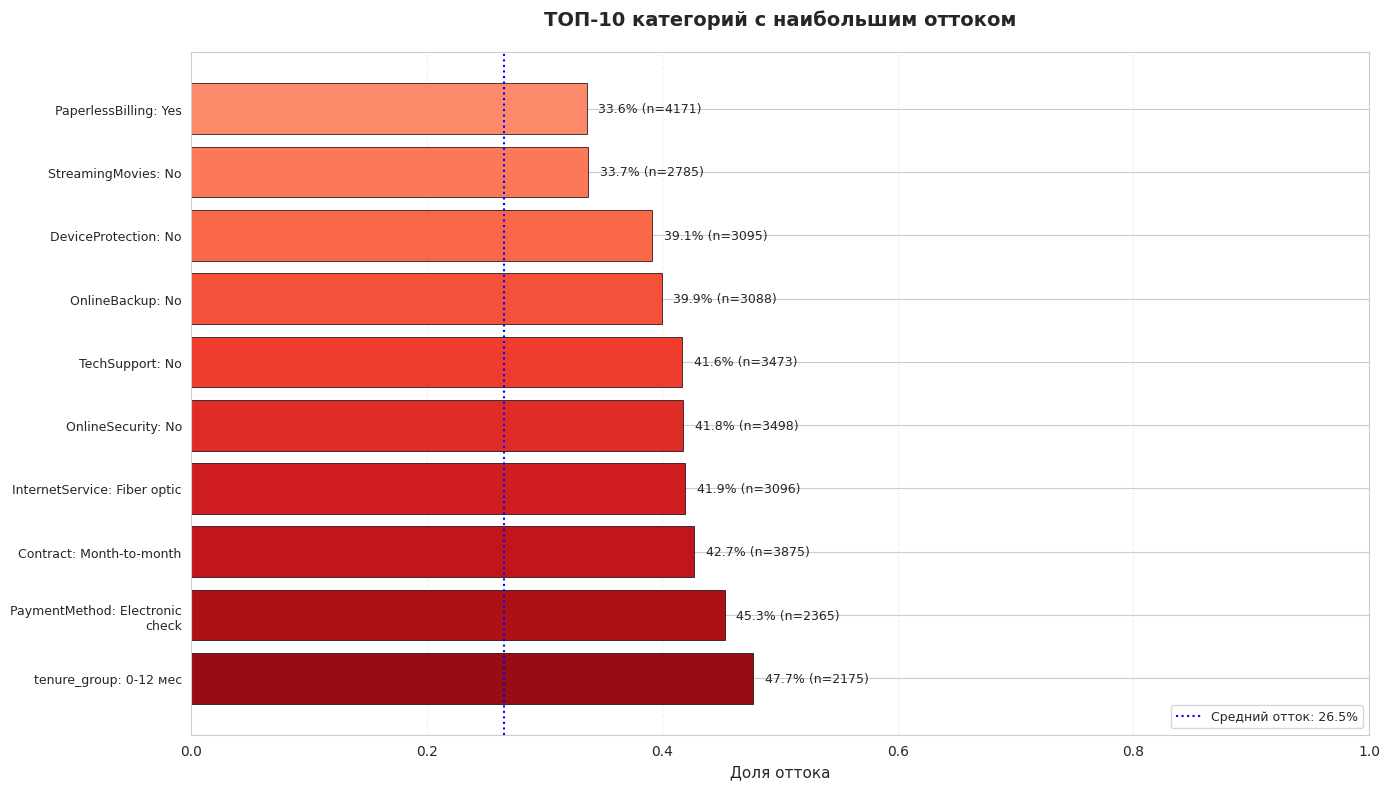

In [30]:
fig5 = visualizer.plot_top_churn_factors(top_n=10, save=True, exclude_cols=['customerID'])
plt.show()

### ГРАФИК 6: СВОДНЫЙ ДАШБОРД

Сохранено: ../images/06_dashboard.png


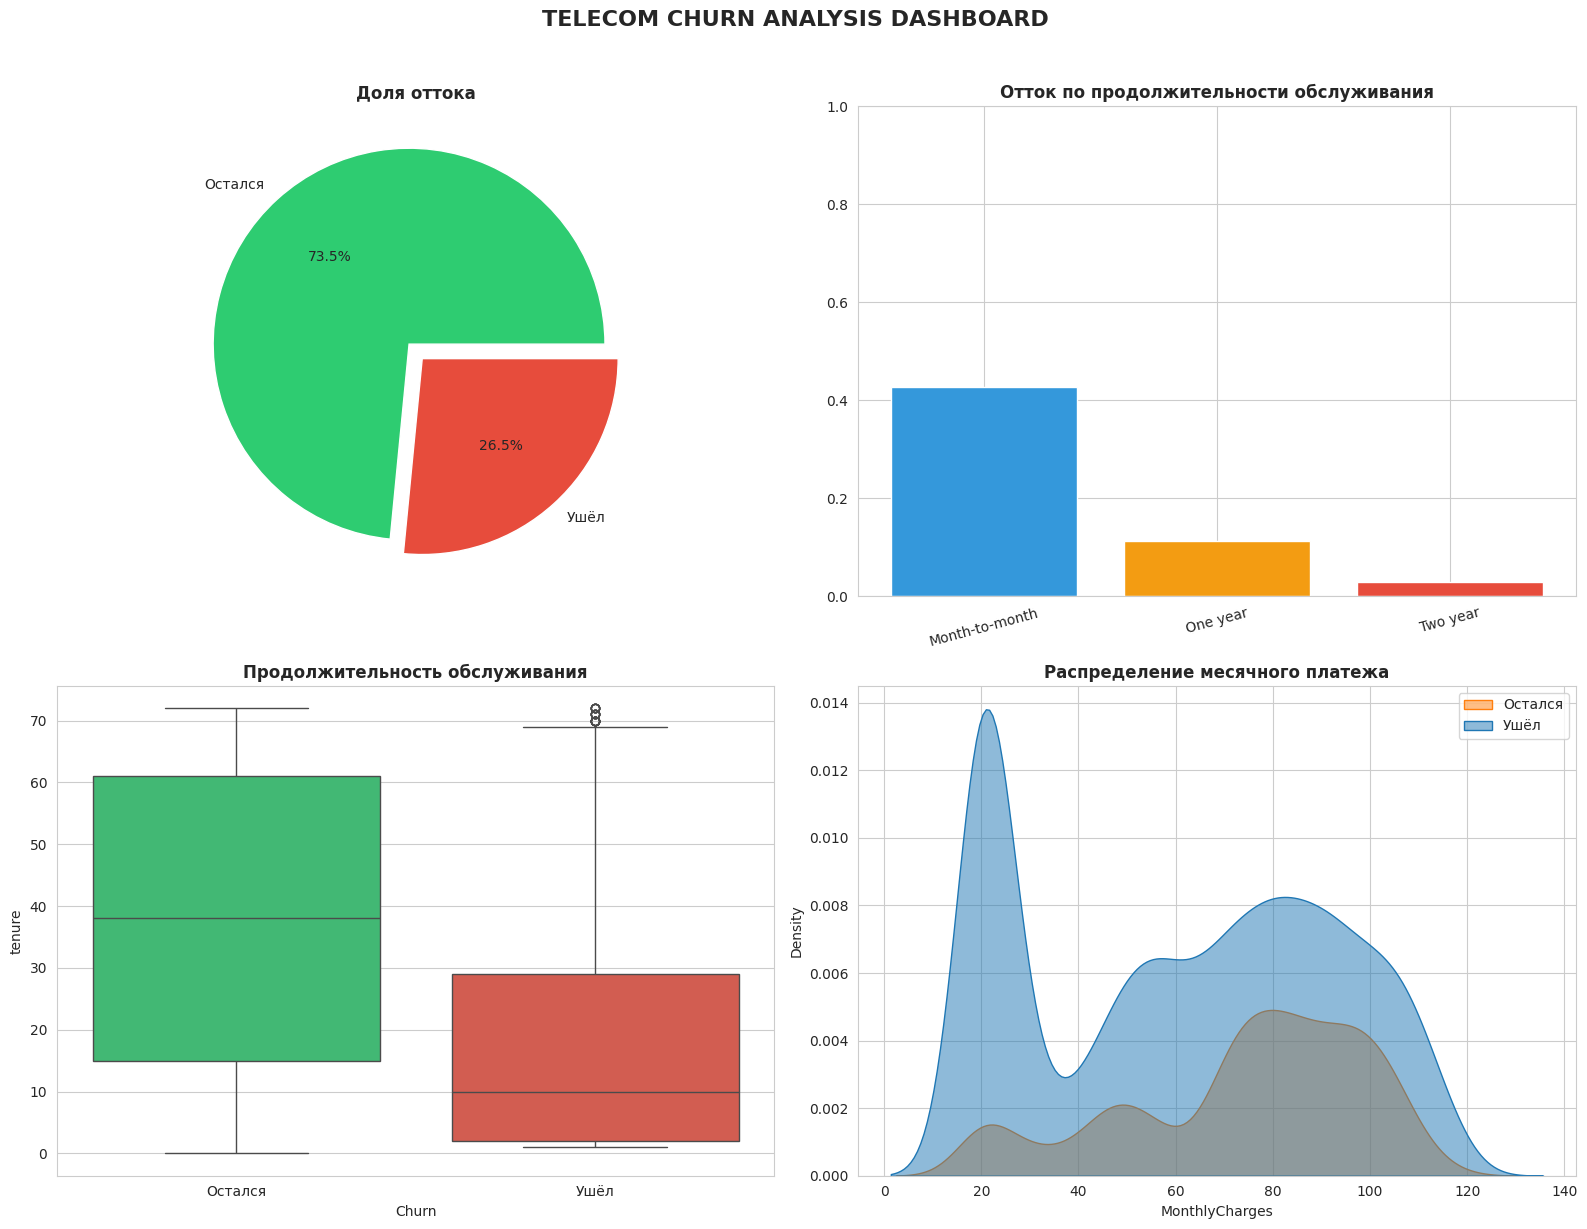

In [31]:
fig6 = visualizer.create_dashboard(save=True)
plt.show()

## Итоги визуализации и готовность к презентации

### Созданные визуализации
| Файл | Описание | Использование |
|------|----------|---------------|
| `01_churn_distribution.png` | Доля оттока (Pie + Count) | Открытие презентации |
| `02_churn_by_contract.png` | Отток по типу контракта | Аргумент за долгосрочные контракты |
| `03_churn_by_tenure.png` | Распределение срока службы | Обоснование фокуса на новых клиентах |
| `04_correlation_heatmap.png` | Корреляционная матрица | Технический слайд для аналитиков |
| `05_top_churn_factors.png` | ТОП-10 категорий по оттоку | Приоритизация мер |
| `06_dashboard.png` | Сводный дашборд 2×2 | Финальный слайд для руководства |

### Принципы визуализации в проекте
1. **Консистентность**: одна цветовая схема (зелёный = остался, красный = ушёл)
2. **Читаемость**: подписи значений, сетка, крупные шрифты
3. **Бизнес-фокус**: заголовки на языке бизнеса, не статистики
4. **Качество**: 300 DPI для печати и презентаций



### 🚀 Готовность к использованию
| Критерий | Статус |
|----------|--------|
| Код структурирован (ООП, модули) | ✅ |
| Все ячейки выполняются без ошибок | ✅ |
| Выводы интерпретированы на языке бизнеса | ✅ |
| Визуализации готовы для презентации | ✅ |
| Проект документирован (README, комментарии) | ✅ |
| Можно показать на собеседовании | ✅ |

### 📬 Контакты и портфолио
Этот проект демонстрирует навыки:
- 🔹 Работа с pandas: загрузка, очистка, трансформация
- 🔹 Разведочный анализ: группировки, агрегации, корреляции
- 🔹 Визуализация: matplotlib, seaborn, дашборды
- 🔹 SQL: агрегации, оконные функции (см. `sql/`)
- 🔹 Бизнес-мышление: инсайты → рекомендации → оценка эффекта

**GitHub:** [твой-репозиторий]  
**LinkedIn:** [твой-профиль]  
**Email:** [твой-email]